# Notebook support pour un projet ML supervisé (classification)
## Notebook 2 - Feature engineering

Commençons par charger les données de sortie de la phase d'EDA.


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib
import math
import matplotlib.pyplot as plt
import seaborn as sns

#Rappel des listes de colonnes :

target = "a_quitte_l_entreprise"

num_cols = [
    "age",
    "revenu_mensuel",
    "nombre_experiences_precedentes",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "satisfaction_employee_environnement",
    "note_evaluation_precedente",
    "niveau_hierarchique_poste",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
    "note_evaluation_actuelle",
    "nombre_participation_pee",
    "nb_formations_suivies",
    "distance_domicile_travail",
    "niveau_education",
    "annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel",
    "augementation_salaire_precedente"
]

cat_cols = [
    "genre",
    "statut_marital",
    "departement",
    "poste",
    "heure_supplementaires",
    "domaine_etude",
    "frequence_deplacement"
]

id_col = ["id_employee"]

drop_cols = [
    "nombre_heures_travailless",
    "nombre_employee_sous_responsabilite",
    "ayant_enfants",
]

#import des données : 
df_FE = pd.read_csv("../data/processed/df_EDA.csv").drop(columns=drop_cols, errors="ignore")
df_FE.shape

(1470, 29)

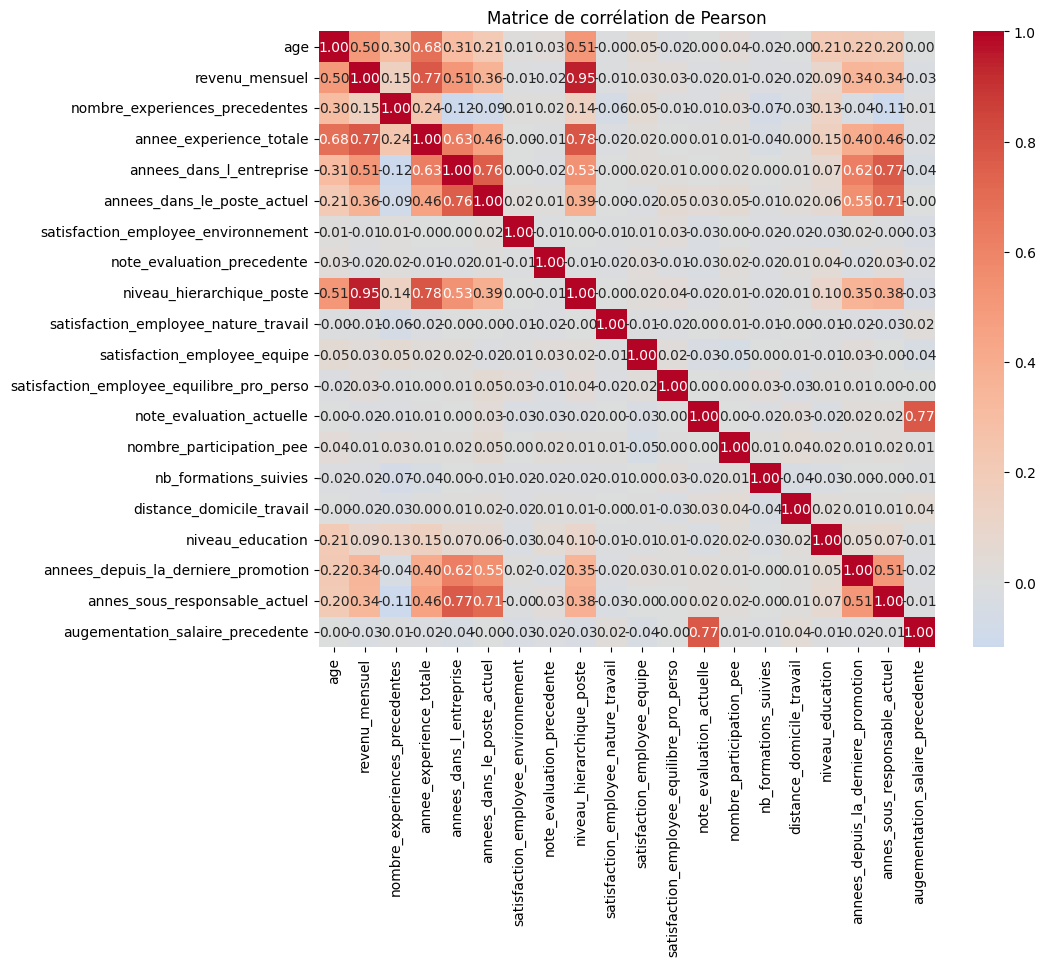

In [2]:
pearson_corr = df_FE[num_cols].corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr,annot=True,fmt=".2f",cmap="coolwarm",center=0,square=True)
plt.title("Matrice de corrélation de Pearson")
plt.show()


Au regard des constats issus de l’EDA, les features suivantes sont identifiées comme candidates à une transformation :

| Feature | Constat issu de l’EDA | Transformation proposée | Objectif |
|---|---|---|---|
| `revenu_mensuel` | Distribution asymétrique à droite, valeurs élevées | Transformation logarithmique (`log1p`) | Réduire l’asymétrie et limiter l’influence des valeurs extrêmes |
| `annee_experience_totale` | Distribution asymétrique à droite | Transformation logarithmique (`log1p`) | Homogénéiser la distribution |
| `annees_dans_l_entreprise` | Distribution asymétrique à droite | Transformation logarithmique (`log1p`) | Réduire l’effet des valeurs extrêmes |
| `annees_dans_le_poste_actuel` | Concentration sur les faibles valeurs | Transformation logarithmique (`log1p`) | Atténuer l’asymétrie |
| `annees_depuis_la_derniere_promotion` | Forte proportion de zéros, asymétrie marquée | Transformation `log1p` | Conserver les zéros tout en réduisant l’asymétrie |
| `annes_sous_responsable_actuel` | Forte proportion de zéros, asymétrie | Transformation `log1p` | Mieux répartir les valeurs élevées |
| `distance_domicile_travail` | Distribution asymétrique | Discrétisation en classes | Faciliter l’interprétation métier |
| `poste` | Certaines modalités sont peu représentées | Regrouper les modalités rares | Stabiliser l’encodage et réduire la dispersion |
| `domaine_etude` | Certaines modalités sont peu fréquentes | Regrouper les modalités rares | Limiter le poids statistique des catégories marginales |


In [11]:
# Copie de travail
df_FE = df_FE.copy()

# 1. Variables à transformer avec log1p
log_cols = [
    "revenu_mensuel",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel",
]

for col in log_cols:
    df_FE[f"{col}_log"] = np.log1p(df_FE[col])

# 2. Discrétisation de la distance domicile-travail en classes
# 0 = proche, 1 = moyenne, 2 = assez loin, 3 = loin, 4=très loin
df_FE["distance_domicile_travail_classe"] = pd.qcut(df_FE["distance_domicile_travail"],q=5,labels=False,duplicates="drop")


# 3. Regroupement des modalités rares pour 'poste'
rare_postes = df_FE["poste"].value_counts()[df_FE["poste"].value_counts() < 100].index
df_FE["poste_regroupe"] = df_FE["poste"].replace(rare_postes, "Autre")

# 4. Regroupement des modalités rares pour 'domaine_etude'
rare_domaines = df_FE["domaine_etude"].value_counts()[df_FE["domaine_etude"].value_counts() < 100].index
df_FE["domaine_etude_regroupe"] = df_FE["domaine_etude"].replace(rare_domaines, "Autre")

df_FE.columns

Index(['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital',
       'departement', 'poste', 'nombre_experiences_precedentes',
       'annee_experience_totale', 'annees_dans_l_entreprise',
       'annees_dans_le_poste_actuel', 'satisfaction_employee_environnement',
       'note_evaluation_precedente', 'niveau_hierarchique_poste',
       'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'augementation_salaire_precedente',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'distance_domicile_travail',
       'niveau_education', 'domaine_etude', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel',
       'revenu_mensuel_log', 'annee_experience_totale_log',
       'annees_dans_l_entreprise_log', 'annees_dans_le_poste_actuel_log',
       'annees_depuis_la_d

In [12]:
df_FE[[f"{col}_log" for col in log_cols]].head()


,revenu_mensuel_log,annee_experience_totale_log,annees_dans_l_entreprise_log,annees_dans_le_poste_actuel_log,annees_depuis_la_derniere_promotion_log,annes_sous_responsable_actuel_log
0,8.698514,2.197225,1.945910,1.609438,0.000000,1.791759
1,8.543056,2.397895,2.397895,2.079442,0.693147,2.079442
2,7.645398,2.079442,0.000000,0.000000,0.000000,0.000000
3,7.975908,2.197225,2.197225,2.079442,1.386294,0.000000
4,8.151622,1.945910,1.098612,1.098612,1.098612,1.098612


In [13]:
df_FE["distance_domicile_travail_classe"].value_counts().sort_index()

distance_domicile_travail_classe
0    419
1    213
2    308
3    253
4    277
Name: count, dtype: int64

In [14]:
df_FE["poste_regroupe"].value_counts()

poste_regroupe
Cadre Commercial          326
Assistant de Direction    292
Consultant                259
Autre                     215
Tech Lead                 145
Manager                   131
Senior Manager            102
Name: count, dtype: int64

In [15]:
df_FE["domaine_etude_regroupe"].value_counts()

domaine_etude_regroupe
Infra & Cloud              606
Transformation Digitale    464
Marketing                  159
Entrepreunariat            132
Autre                      109
Name: count, dtype: int64

## Feature engineering

On commence par créer des features en lien avec l'ancienneté et le parcours dans l'entreprise :


In [16]:
df_FE["ratio_anciennete_poste"] = (df_FE["annees_dans_le_poste_actuel"] / (df_FE["annees_dans_l_entreprise"] + 1))

df_FE["ratio_anciennete_manager"] = (df_FE["annes_sous_responsable_actuel"] / (df_FE["annees_dans_l_entreprise"] + 1))

df_FE["ratio_experience_entreprise"] = (df_FE["annees_dans_l_entreprise"] / (df_FE["annee_experience_totale"] + 1))

df_FE["mobilite_interne_potentielle"] = (df_FE["annees_dans_l_entreprise"] - df_FE["annees_dans_le_poste_actuel"])

Promotion / progression de carrière :


In [17]:
# Hypothèse retenue :
# 0 an depuis la dernière promotion = promotion récente / pas d'attente actuelle

df_FE["jamais_promu"] = (df_FE["annees_depuis_la_derniere_promotion"] == 0).astype(int)

df_FE["retard_promotion_relatif"] = (df_FE["annees_depuis_la_derniere_promotion"] / (df_FE["annees_dans_l_entreprise"] + 1))

seuil_augmentation_faible = df_FE["augementation_salaire_precedente"].median()
df_FE["progression_salariale_faible"] = (df_FE["augementation_salaire_precedente"] < seuil_augmentation_faible).astype(int)

Rémunération relative :


In [18]:
# Référence par niveau hiérarchique
df_FE["mediane_revenu_par_niveau"] = (df_FE.groupby("niveau_hierarchique_poste")["revenu_mensuel"].transform("median"))

df_FE["revenu_par_niveau"] = (df_FE["revenu_mensuel"] / df_FE["mediane_revenu_par_niveau"])

df_FE["sous_remunere_niveau"] = (df_FE["revenu_mensuel"] < df_FE["mediane_revenu_par_niveau"]).astype(int)

# Référence par poste (utilise poste_regroupe si déjà créé, sinon poste)
poste_ref_col = "poste_regroupe" if "poste_regroupe" in df_FE.columns else "poste"

df_FE["mediane_revenu_par_poste"] = (df_FE.groupby(poste_ref_col)["revenu_mensuel"].transform("median"))

df_FE["revenu_par_poste"] = (df_FE["revenu_mensuel"] / df_FE["mediane_revenu_par_poste"])

Cohérence performance / reconnaissance :


In [19]:
df_FE["evolution_evaluation"] = (df_FE["note_evaluation_actuelle"] - df_FE["note_evaluation_precedente"])

# Bonne performance = valeur maximale observée sur la note actuelle
seuil_bonne_perf = df_FE["note_evaluation_actuelle"].max()

df_FE["bonne_perf_peu_augmente"] = ((df_FE["note_evaluation_actuelle"] >= seuil_bonne_perf) & (df_FE["augementation_salaire_precedente"] < seuil_augmentation_faible)).astype(int)

In [20]:
nouvelles_cols_nums = [
    "ratio_anciennete_poste",
    "ratio_anciennete_manager",
    "ratio_experience_entreprise",
    "retard_promotion_relatif",
    "revenu_par_niveau",
    "revenu_par_poste"
]

nouvelles_cols_cat = [
    "mobilite_interne_potentielle",
    "jamais_promu",
    "progression_salariale_faible",
    "sous_remunere_niveau",
    "evolution_evaluation",
    "bonne_perf_peu_augmente"
]

nouvelles_cols = nouvelles_cols_cat + nouvelles_cols_nums

df_FE[nouvelles_cols].head()

,mobilite_interne_potentielle,jamais_promu,progression_salariale_faible,sous_remunere_niveau,evolution_evaluation,bonne_perf_peu_augmente,ratio_anciennete_poste,ratio_anciennete_manager,ratio_experience_entreprise,retard_promotion_relatif,revenu_par_niveau,revenu_par_poste
0,2,1,1,0,0,0,0.571429,0.714286,0.666667,0.000000,1.122285,0.961804
1,3,0,0,1,2,0,0.636364,0.636364,0.909091,0.090909,0.960674,1.776623
2,0,1,0,1,1,0,0.000000,0.000000,0.000000,0.000000,0.782772,0.724186
3,1,0,1,0,0,0,0.777778,0.000000,0.888889,0.333333,1.089513,1.007446
4,0,0,1,0,0,0,0.666667,0.666667,0.285714,0.666667,1.298876,1.201663


## Vérification des corrélations linéaires


In [21]:
num_cols = [
    "age",
    "revenu_mensuel",
    "nombre_experiences_precedentes",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "satisfaction_employee_environnement",
    "note_evaluation_precedente",
    "niveau_hierarchique_poste",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
    "note_evaluation_actuelle",
    "nombre_participation_pee",
    "nb_formations_suivies",
    "distance_domicile_travail",
    "niveau_education",
    "annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel",
    "augementation_salaire_precedente",
]



# Variables numériques mais ordinales => exclues de Pearson
ordinal_num_cols = [
    "satisfaction_employee_environnement",
    "note_evaluation_precedente",
    "niveau_hierarchique_poste",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
    "note_evaluation_actuelle",
    "niveau_education",
]

# Sous-ensemble pour l'analyse
corr_candidates = num_cols + nouvelles_cols_nums

# Matrice de corrélation de Pearson
corr_matrix = df_FE[corr_candidates].corr(method="pearson")

# Extraction des paires uniques
corr_pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().reset_index())
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

# Filtre : corrélation absolue > 0.6
strong_corr = (corr_pairs[corr_pairs["abs_correlation"] > 0.6].sort_values("abs_correlation", ascending=False).reset_index(drop=True))
strong_corr[["feature_1", "feature_2", "correlation"]]


,feature_1,feature_2,correlation
0,revenu_mensuel,niveau_hierarchique_poste,0.950300
1,annee_experience_totale,niveau_hierarchique_poste,0.782208
2,note_evaluation_actuelle,augementation_salaire_precedente,0.773550
3,revenu_mensuel,annee_experience_totale,0.772893
4,annees_dans_l_entreprise,annes_sous_responsable_actuel,0.769212
5,annees_dans_l_entreprise,annees_dans_le_poste_actuel,0.758754
6,annees_depuis_la_derniere_promotion,retard_promotion_relatif,0.744830
7,annees_dans_le_poste_actuel,annes_sous_responsable_actuel,0.714365
8,annes_sous_responsable_actuel,ratio_anciennete_manager,0.682157
9,age,annee_experience_totale,0.680381


## Diagrammes pairplot


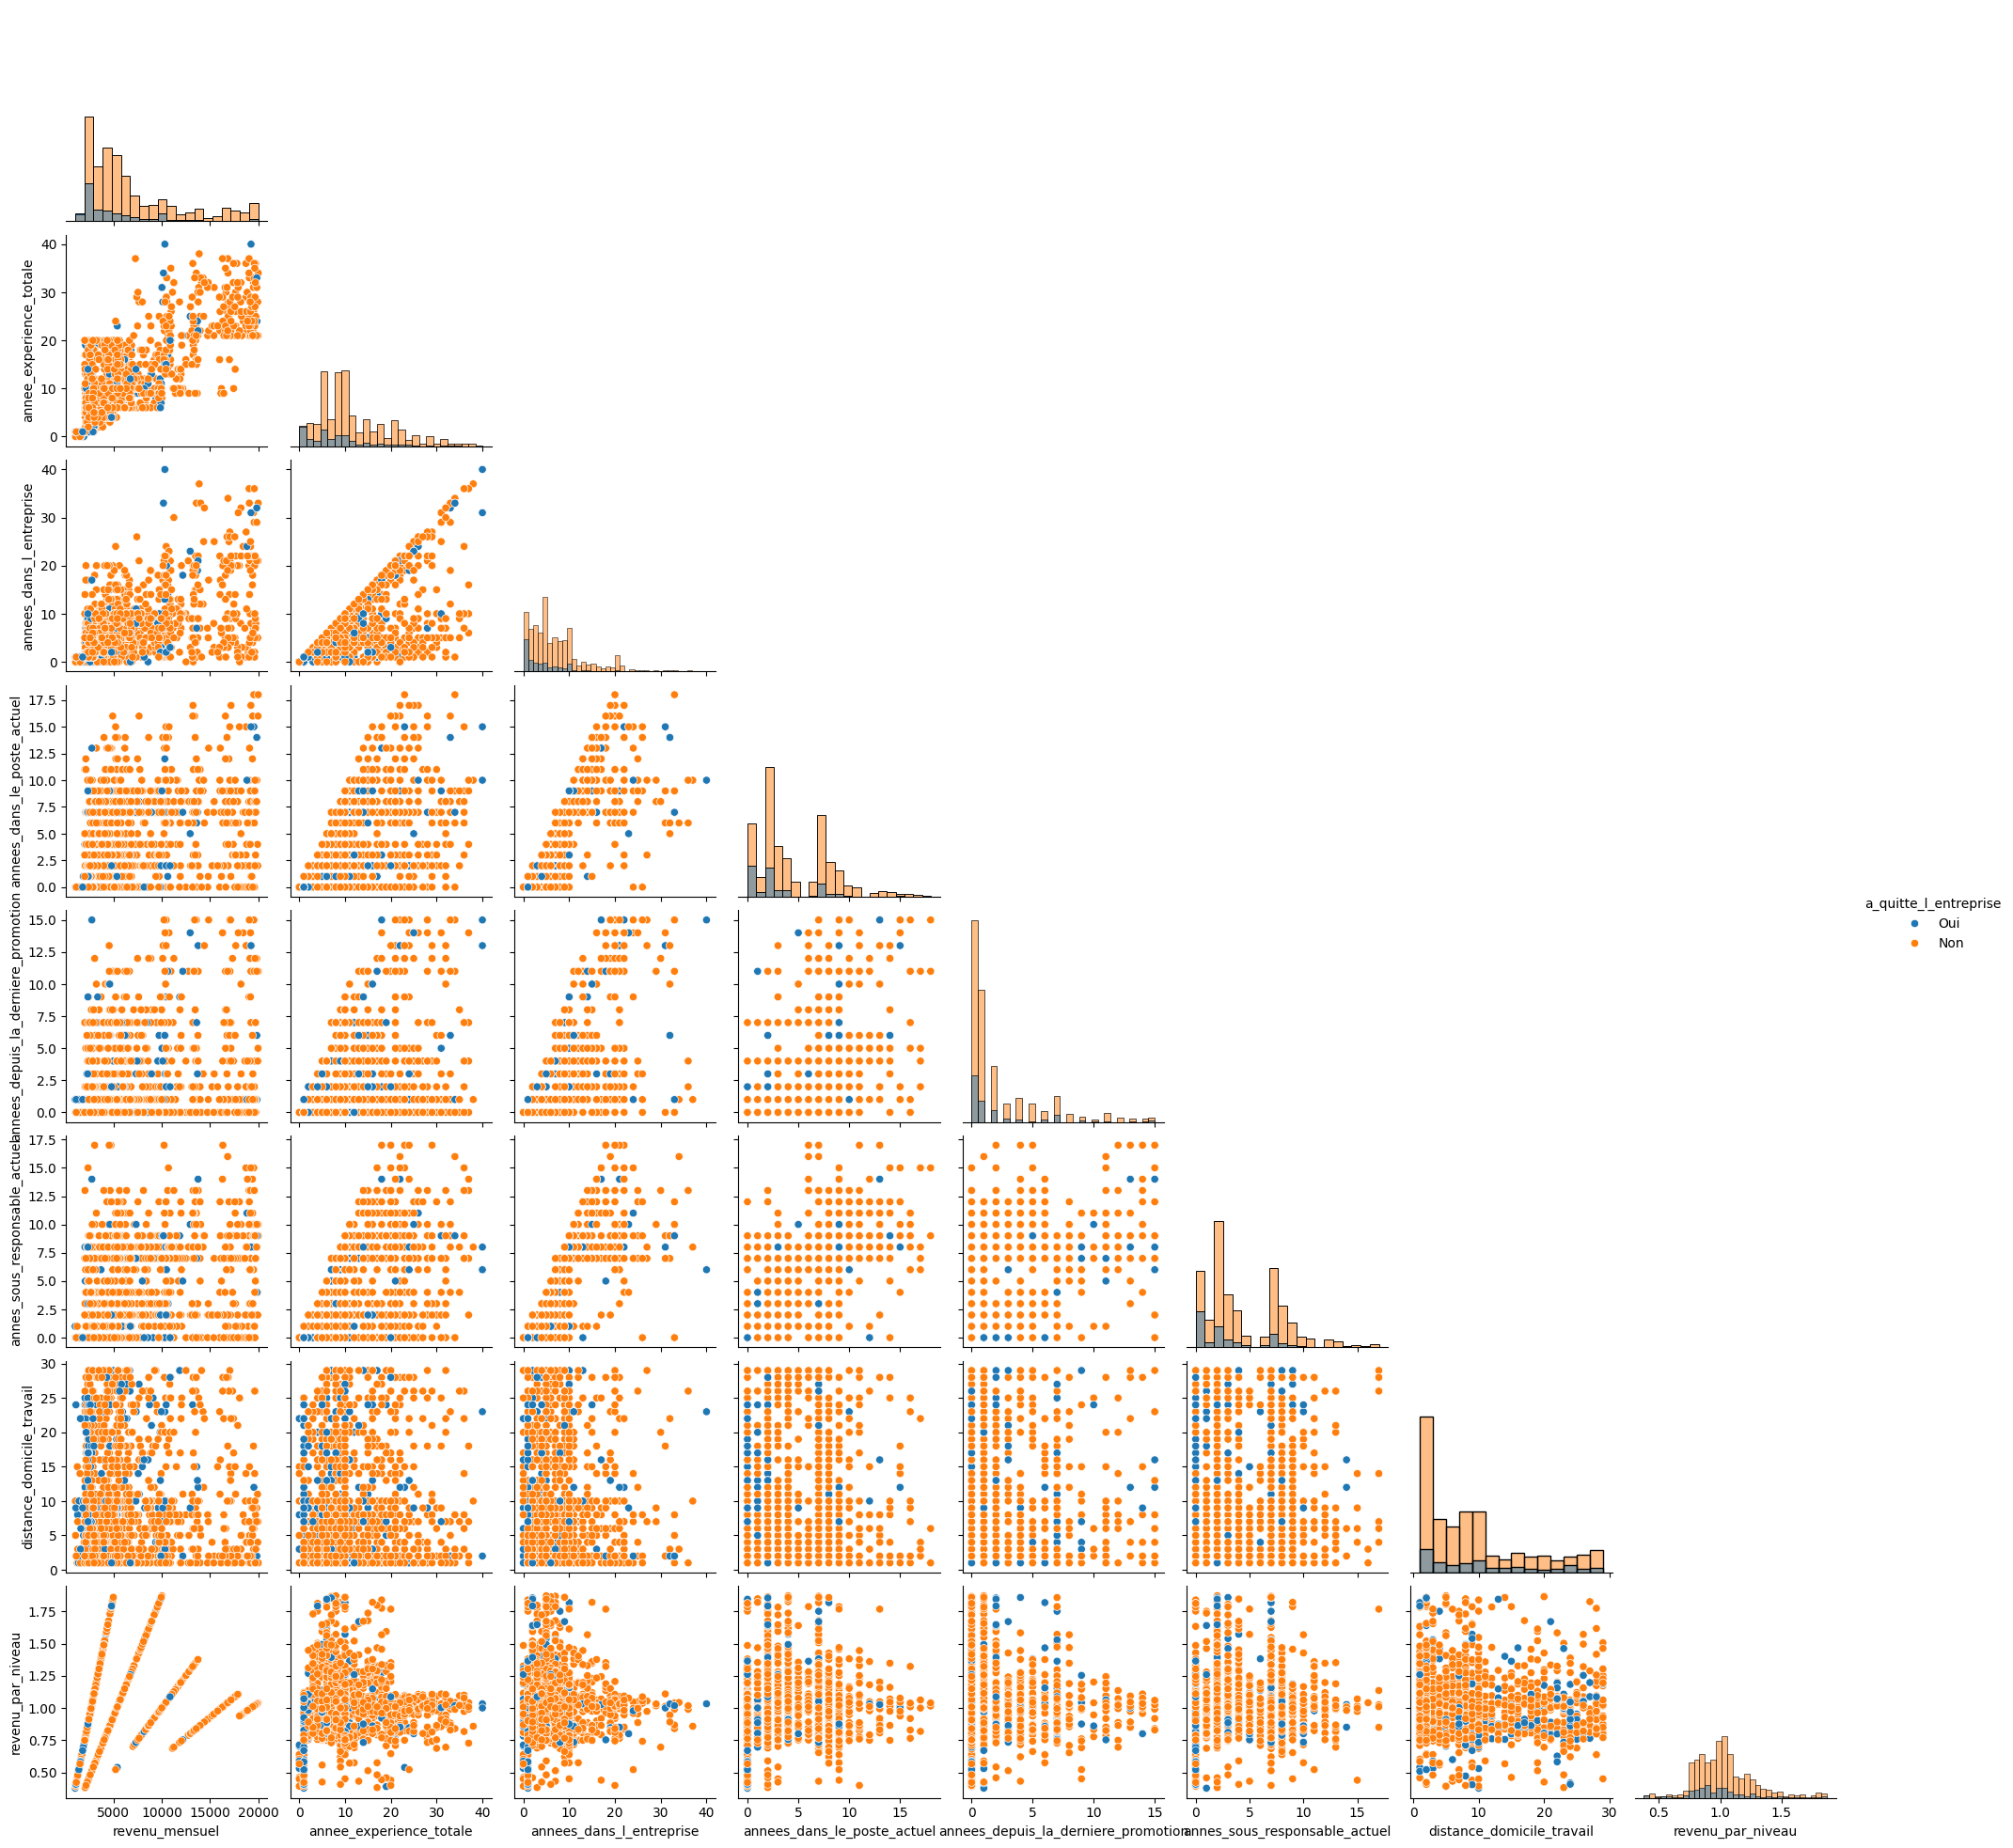

In [22]:
pairplot_cols = [
    "revenu_mensuel",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel",
    "distance_domicile_travail",
    "revenu_par_niveau",
]

sns.pairplot(df_FE[pairplot_cols + [target]],hue=target,corner=True,diag_kind="hist")

plt.show()


Le pairplot met principalement en évidence des relations monotones positives entre les variables d’expérience, d’ancienneté et de rémunération.  
Les dépendances observées sont globalement cohérentes avec la logique métier : le revenu tend à augmenter avec l’expérience totale, tandis que les différentes mesures d’ancienneté évoluent ensemble de manière attendue.

Les relations observées ne semblent pas révéler de non-linéarités complexes marquées.  
On observe surtout des tendances croissantes, parfois par paliers, liées au caractère discret de plusieurs variables.  
Cela suggère que les corrélations détectées précédemment par Pearson traduisent principalement des dépendances structurelles réelles, et non des artefacts purement non linéaires.

Enfin, les observations associées aux deux classes de la cible (`Oui` / `Non`) restent très largement superposées dans les projections à deux dimensions. Cela confirme qu’aucune variable, ni aucune paire de variables prise isolément, ne permet de discriminer clairement le départ de l’entreprise, ce qui plaide pour une approche multivariée lors de la modélisation.


## Corrélation de Spearman :

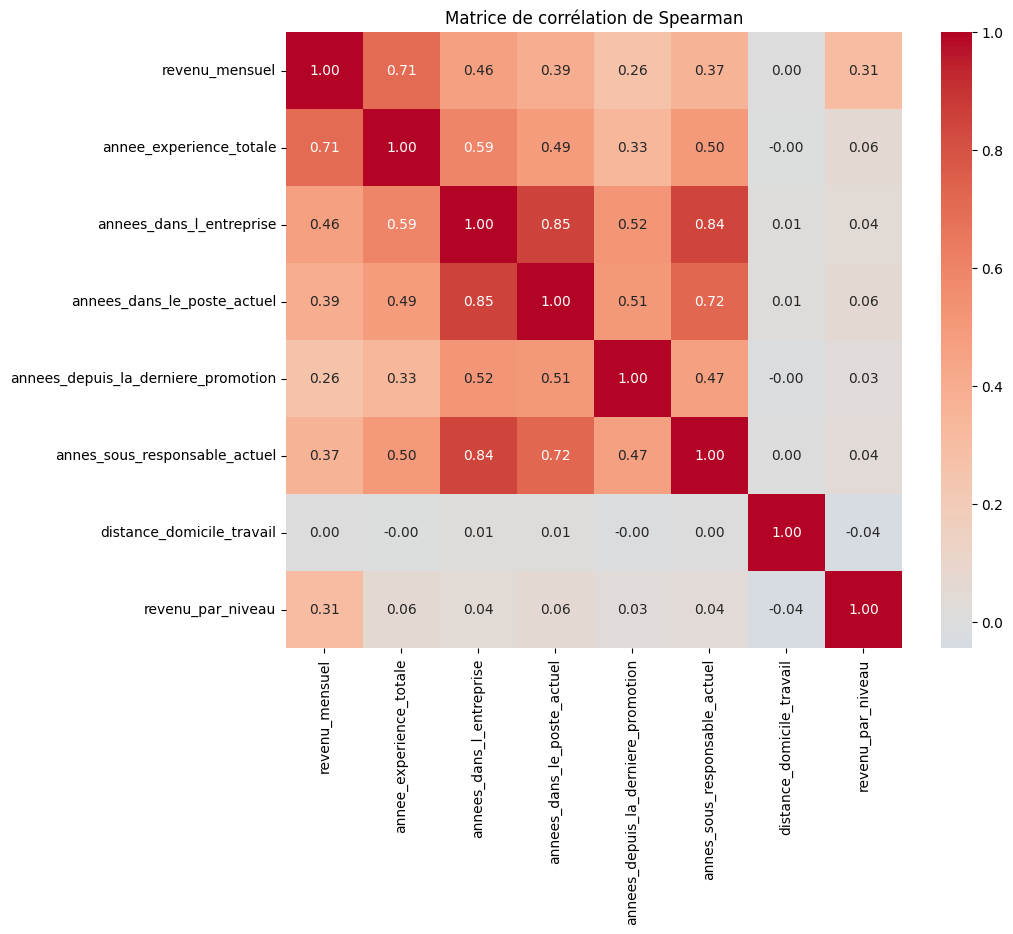

In [23]:
spearman_corr = df_FE[pairplot_cols].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr,annot=True,fmt=".2f",cmap="coolwarm",center=0,square=True)
plt.title("Matrice de corrélation de Spearman")
plt.show()


## Analyse complémentaire des corrélations monotones (Spearman)

La matrice de Spearman confirme surtout une forte redondance dans la description des phénomènes d'ancienneté interne :  
`annees_dans_le_poste_actuel` et `annes_sous_responsable_actuel` sont fortement corrélées avec `annees_dans_l_entreprise`.    
`revenu_mensuel` est également nettement corrélé à `annee_experience_totale`, ce qui traduit une progression salariale globalement liée à l’expérience.  

À l’inverse, `distance_domicile_travail` ne présente pratiquement aucune corrélation avec les autres variables et semble donc apporter une information indépendante.   
Enfin, `revenu_par_niveau` reste faiblement corrélé au reste du jeu de variables, ce qui en fait une variable potentiellement complémentaire plutôt que redondante.  
 

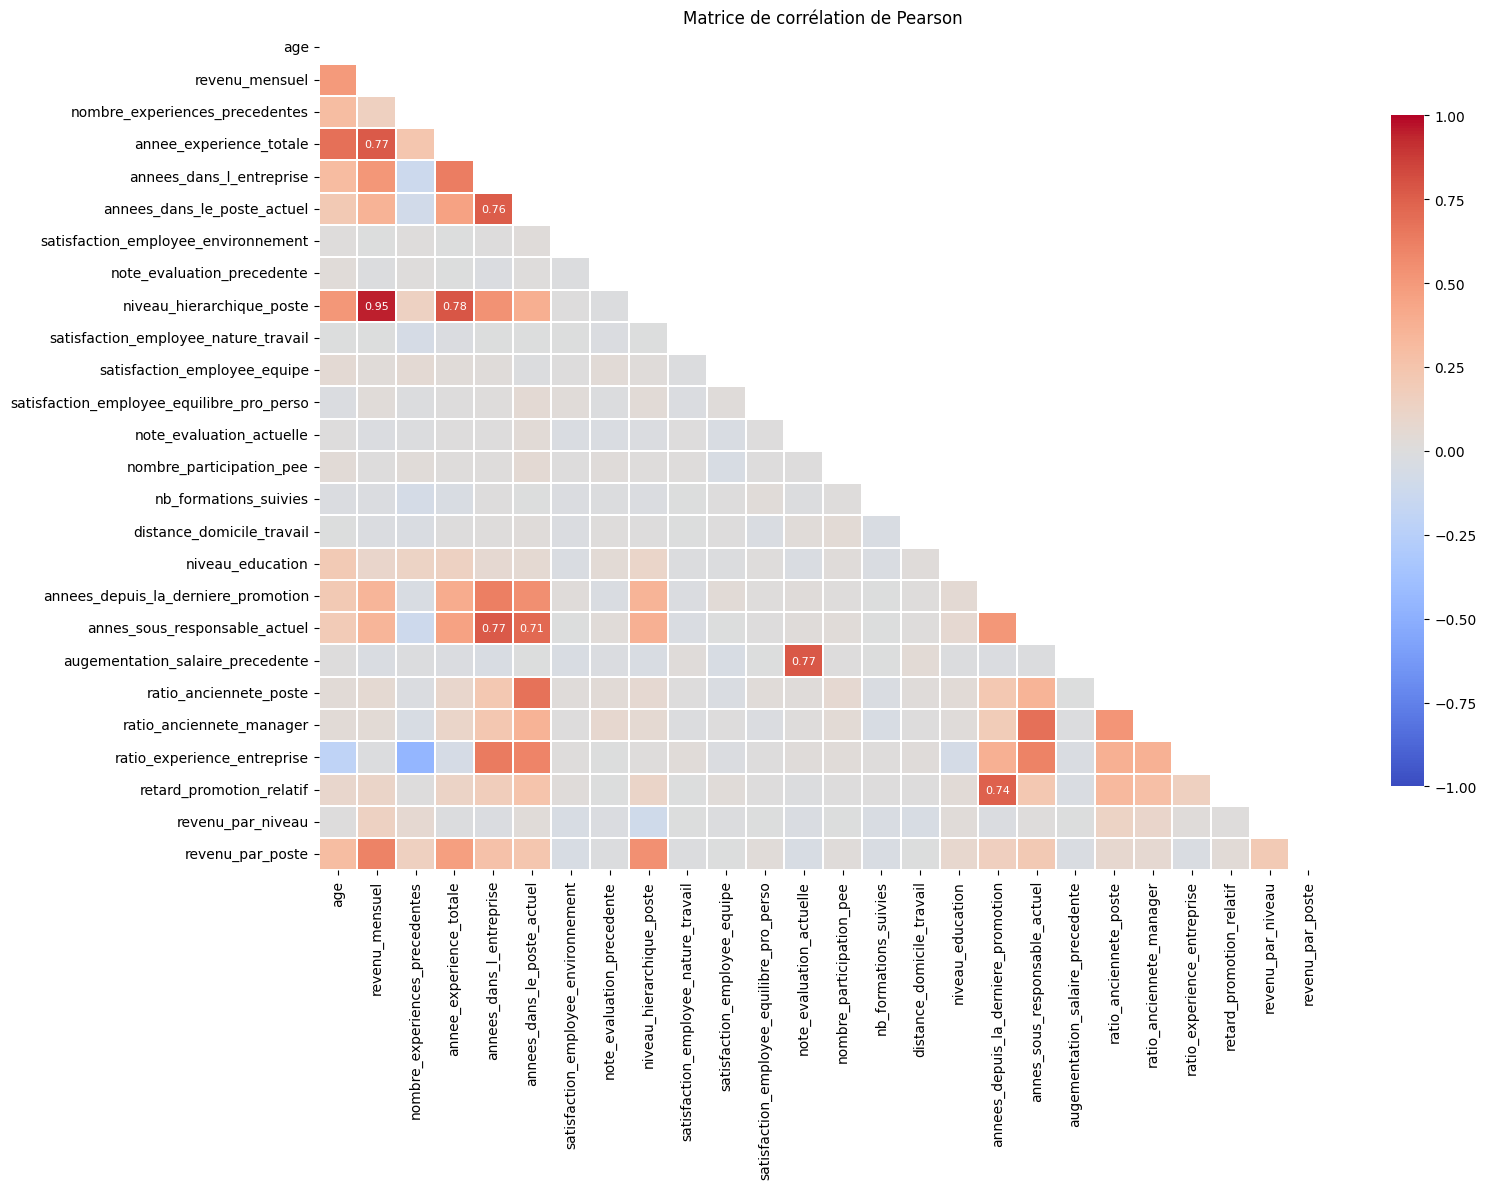

In [27]:
corr = df_FE[num_cols + nouvelles_cols_nums].corr(method="pearson")

mask = np.triu(np.ones_like(corr, dtype=bool))

annot_text = corr.map(lambda x: f"{x:.2f}" if abs(x) >= 0.70 else "")

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=False,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8},
    annot=annot_text,
    fmt="",
    annot_kws={"size": 8}
)

plt.title("Matrice de corrélation de Pearson")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [28]:
#On commence par supprimer cette liste, les lignes en commentaires pourraient être supprimées après avoir fait un premier jet de modèles d'essais.

#cols_to_drop_fe = [
    #"progression_salariale_faible",
    #"sous_remunere_niveau",
    #"jamais_promu",
    #"mediane_revenu_par_niveau",
    #"mediane_revenu_par_poste",
    #"annes_sous_responsable_actuel",
    #"annees_depuis_la_derniere_promotion",
#]

#df_FE = df_FE.drop(columns=cols_to_drop_fe, errors="ignore")
df_FE.shape

(1470, 52)

## Encodage des variables catégorielles

Les méthodes d’encodage sont choisies en fonction du sens métier des variables qualitatives.  
Les variables binaires (`genre`, `heure_supplementaires`) sont transformées en variables numériques `0/1`.  
Les variables nominales sans ordre naturel (`statut_marital`, `departement`, `poste_regroupe`, `domaine_etude_regroupe`) seront encodées par one-hot encoding.  
Enfin, `frequence_deplacement` peut être traitée comme une variable ordinale au sens métier : `Aucun < Occasionnel < Fréquent`.


In [29]:
binary_cols = ["genre", "heure_supplementaires"]
nominal_cols = ["statut_marital", "departement", "poste_regroupe", "domaine_etude_regroupe"]
ordinal_cols = ["frequence_deplacement"] 

import sys
from pathlib import Path
import importlib

sys.path.append(str(Path("../").resolve()))

import src.Fonctions_MODEL as Fonctions_MODEL
importlib.reload(Fonctions_MODEL)

df_MODEL = df_FE.copy()
df_MODEL["a_quitte_l_entreprise"] = df_MODEL["a_quitte_l_entreprise"].map({"Non": 0, "Oui": 1})
df_MODEL["genre"] = df_MODEL["genre"].map({"F": 0, "M": 1})
df_MODEL["heure_supplementaires"] = df_MODEL["heure_supplementaires"].map({"Non": 0, "Oui": 1})

df_MODEL, enc_statut = Fonctions_MODEL.encode_cat_col(df_MODEL, "statut_marital", "onehot")
df_MODEL, enc_dept = Fonctions_MODEL.encode_cat_col(df_MODEL, "departement", "onehot")
df_MODEL, enc_freq = Fonctions_MODEL.encode_cat_col(df_MODEL, "frequence_deplacement", "onehot")
df_MODEL, enc_poste = Fonctions_MODEL.encode_cat_col(df_MODEL, "poste_regroupe", "onehot")
df_MODEL, enc_domaine = Fonctions_MODEL.encode_cat_col(df_MODEL, "domaine_etude_regroupe", "onehot")
df_MODEL.shape


(1470, 68)

In [30]:
[col for col in ["statut_marital", "departement", "frequence_deplacement", "poste", "poste_regroupe", "domaine_etude", "domaine_etude_regroupe"] if col in df_MODEL.columns]


['poste', 'domaine_etude']

In [32]:
cols_to_drop_model = [
    "poste",
    "domaine_etude",
]

df_MODEL = df_MODEL.drop(columns=cols_to_drop_model, errors="ignore")

In [33]:
print(df_MODEL.shape)
print(df_MODEL.dtypes.value_counts())
df_MODEL.head()

(1470, 66)
float64    36
int64      30
Name: count, dtype: int64


,id_employee,age,genre,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,...,poste_regroupe_Cadre Commercial,poste_regroupe_Consultant,poste_regroupe_Manager,poste_regroupe_Senior Manager,poste_regroupe_Tech Lead,domaine_etude_regroupe_Autre,domaine_etude_regroupe_Entrepreunariat,domaine_etude_regroupe_Infra & Cloud,domaine_etude_regroupe_Marketing,domaine_etude_regroupe_Transformation Digitale
0,1,41,0,5993,8,8,6,4,2,3,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2,49,1,5130,1,10,10,7,3,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,4,37,1,2090,6,7,0,0,4,2,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,5,33,0,2909,1,8,8,7,4,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,7,27,1,3468,9,6,2,2,1,3,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [34]:
df_MODEL.columns

Index(['id_employee', 'age', 'genre', 'revenu_mensuel',
       'nombre_experiences_precedentes', 'annee_experience_totale',
       'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'augementation_salaire_precedente',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'distance_domicile_travail',
       'niveau_education', 'annees_depuis_la_derniere_promotion',
       'annes_sous_responsable_actuel', 'revenu_mensuel_log',
       'annee_experience_totale_log', 'annees_dans_l_entreprise_log',
       'annees_dans_le_poste_actuel_log',
       'annees_depuis_la_derniere_promotion_log',
       'annes_sous_responsable_actuel_log', 'distance_domici

## Export du DataFrame après feature engineering

Le jeu `df_MODEL` obtenu en sortie contient **1 470 lignes et 60 colonnes**.  
Il constitue la base de travail prête pour la modélisation supervisée, après transformations, créations de variables et encodage des variables catégorielles retenues.


In [35]:
cols_brutes_remplacees_par_log = [
    "revenu_mensuel",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel",
]

df_MODEL = df_MODEL.drop(columns=cols_brutes_remplacees_par_log)

df_MODEL.shape

(1470, 60)

In [36]:
from pathlib import Path
output_path = Path("../data/processed/df_MODEL.csv")
df_MODEL.to_csv(output_path, index=False)
